# 데이터 전처리

## 결측값

In [4]:
import pandas as pd

score = pd.Series([30, 20, 40, pd.NA, 30, pd.NA])
print(score)
print(score.sum())
print(score.mean())
print(score+5)

pd.isna(score)
pd.isna(score).sum()

print(score.size)
print(score.count())

pd.notna(score)
pd.notna(score).sum()

score= score.dropna()
print(score)
score = score.reset_index(drop=True)
print(score)


0      30
1      20
2      40
3    <NA>
4      30
5    <NA>
dtype: object
120
30.0
0      35
1      25
2      45
3    <NA>
4      35
5    <NA>
dtype: object
6
4
0    30
1    20
2    40
4    30
dtype: object
0    30
1    20
2    40
3    30
dtype: object


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/iris.csv')
df.iloc[0, 1] = pd.NA ; df.iloc[0, 2] = pd.NA
df.iloc[1, 2] = np.nan ; df.iloc[2,3] = None
print(df.head())

df.isnull().sum()
df.isnull().sum(axis=1)
df.loc[df.isnull().sum(axis=1) > 0, :]

df= df.dropna()
df= df.reset_index(drop=True)
print(df.head())

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          NaN           NaN          0.2  setosa
1           4.9          3.0           NaN          0.2  setosa
2           4.7          3.2           1.3          NaN  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           4.6          3.1           1.5          0.2  setosa
1           5.0          3.6           1.4          0.2  setosa
2           5.4          3.9           1.7          0.4  setosa
3           4.6          3.4           1.4          0.3  setosa
4           5.0          3.4           1.5          0.2  setosa


In [11]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

df_org = pd.read_csv('data/iris.csv')
df_miss = df_org.copy()

df_miss.iloc[0, 3] = pd.NA ; df_miss.iloc[0, 2] = pd.NA
df_miss.iloc[1, 2] = None ; df_miss.iloc[2, 3] = None
print(df_miss.head(4), '\n')

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_miss.iloc[:, :4])
print(df_scaled[0:5, :], '\n')

imputer = KNNImputer(n_neighbors=5)
df_scaled = imputer.fit_transform(df_scaled)
print(df_scaled[0:5, :], '\n')

df_filled = scaler.inverse_transform(df_scaled)
print(df_filled[0:5, :], '\n')

df_miss.iloc[:, :4] = df_filled

print(df_miss.head(4), '\n')
print(df_org.head(4))


   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           NaN          NaN  setosa
1           4.9          3.0           NaN          0.2  setosa
2           4.7          3.2           1.3          NaN  setosa
3           4.6          3.1           1.5          0.2  setosa 

[[0.22222222 0.625             nan        nan]
 [0.16666667 0.41666667        nan 0.04166667]
 [0.11111111 0.5        0.05084746        nan]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]] 

[[0.22222222 0.625      0.0779661  0.09166667]
 [0.16666667 0.41666667 0.08474576 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]] 

[[5.1  3.5  1.46 0.32]
 [4.9  3.   1.5  0.2 ]
 [4.7  3.2  1.3  0.2 ]
 [4.6  3.1  1.5  0.2 ]
 [5.   3.6  1.4  0.2 ]] 

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1     

## 특잇값

In [3]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('data/iris.csv')
sw = df.Sepal_Width

z = np.abs(stats.zscore(sw))
outliers = sw[z > 2]
print(outliers, '\n')

Q1 = sw.quantile(0.25)
Q3 = sw.quantile(0.75)
IQR = Q3 - Q1

outliers = sw[(sw < Q1 - IQR * 1.5) | (sw > Q3 + IQR * 1.5)]
print(outliers)

clean = sw.loc[~sw.isin(outliers)]
len(clean)

14    4.0
15    4.4
32    4.1
33    4.2
60    2.0
Name: Sepal_Width, dtype: float64 

15    4.4
32    4.1
33    4.2
60    2.0
Name: Sepal_Width, dtype: float64


146

## 정렬과 순위

In [12]:
import pandas as pd
df = pd.read_csv('data/iris.csv')

df_sorted = df.sort_values('Sepal_Length')
print(df_sorted.head(10), '\n')

df_sorted = df.sort_values('Sepal_Length', ascending=False)
print(df_sorted.head(10), '\n')

df_sorted = df.sort_values(['Species', 'Sepal_Length'])
print(df_sorted.head(10), '\n')

print(df['Petal_Length'].rank(), '\n')
print(df['Petal_Length'].rank().astype(int), '\n')
print(df['Petal_Length'].rank(ascending=False).astype(int))

    Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
13           4.3          3.0           1.1          0.1  setosa
8            4.4          2.9           1.4          0.2  setosa
42           4.4          3.2           1.3          0.2  setosa
38           4.4          3.0           1.3          0.2  setosa
41           4.5          2.3           1.3          0.3  setosa
22           4.6          3.6           1.0          0.2  setosa
3            4.6          3.1           1.5          0.2  setosa
6            4.6          3.4           1.4          0.3  setosa
47           4.6          3.2           1.4          0.2  setosa
2            4.7          3.2           1.3          0.2  setosa 

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width    Species
131           7.9          3.8           6.4          2.0  virginica
122           7.7          2.8           6.7          2.0  virginica
118           7.7          2.6           6.9          2.3  virginica
117    

## 데이터 샘플링, 조합

In [14]:
import pandas as pd
import itertools

df = pd.read_csv('data/iris.csv')

df20 = df.sample(n=20, random_state=123)
print(df20, '\n')

stratified = df.groupby('Species').apply(lambda x: x.sample(frac=0.2, random_state=123))
print(stratified, '\n')

species = df.Species.unique()

comb = list(itertools.combinations(species, 2))
print(comb)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width     Species
72            6.3          2.5           4.9          1.5  versicolor
112           6.8          3.0           5.5          2.1   virginica
132           6.4          2.8           5.6          2.2   virginica
88            5.6          3.0           4.1          1.3  versicolor
37            4.9          3.6           1.4          0.1      setosa
138           6.0          3.0           4.8          1.8   virginica
87            6.3          2.3           4.4          1.3  versicolor
42            4.4          3.2           1.3          0.2      setosa
8             4.4          2.9           1.4          0.2      setosa
90            5.5          2.6           4.4          1.2  versicolor
141           6.9          3.1           5.1          2.3   virginica
33            5.5          4.2           1.4          0.2      setosa
59            5.2          2.7           3.9          1.4  versicolor
116           6.5   

C:\Users\user\AppData\Local\Temp\ipykernel_39956\3463107278.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified = df.groupby('Species').apply(lambda x: x.sample(frac=0.2, random_state=123))


## 데이터 집계와 병합

In [16]:
import pandas as pd
df = pd.read_csv('data/iris.csv')

df_agg = df.groupby('Species').mean()
print(df_agg,'\n')

df_agg = df.groupby('Species').std()
print(df_agg)

            Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
Species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026 

            Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
Species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


In [ ]:
import pandas as pd

df1 = pd.DataFrame([[169, 58, 1.0],

[172, 73, 1.2],

[184, 82, 0.7]],

columns=['height', 'weight', 'eye'])

print(df1, '\n')

df2 = pd.DataFrame([[176, 71, 0.8, 'M'],

[169, 62, 0.7, 'F'],

[158, 60, 1.3, 'M']],

columns=['height', 'weight', 'eye', 'gender'])

print(df2, '\n')

df3 = pd.DataFrame([[3, 22],

[2, 21]],

columns=['grade', 'age'])

print(df3)

df12 = pd.concat([df1, df2])
print(df12)
df12 = df12.reset_index(drop=True)
print(df12)
df13 = pd.concat([df1, df3], axis =1)
print(df13)


   height  weight  eye
0     169      58  1.0
1     172      73  1.2
2     184      82  0.7 

   height  weight  eye gender
0     176      71  0.8      M
1     169      62  0.7      F
2     158      60  1.3      M 

   grade  age
0      3   22
1      2   21
   height  weight  eye gender
0     169      58  1.0    NaN
1     172      73  1.2    NaN
2     184      82  0.7    NaN
0     176      71  0.8      M
1     169      62  0.7      F
2     158      60  1.3      M
   height  weight  eye gender
0     169      58  1.0    NaN
1     172      73  1.2    NaN
2     184      82  0.7    NaN
3     176      71  0.8      M
4     169      62  0.7      F
5     158      60  1.3      M
   height  weight  eye  grade   age
0     169      58  1.0    3.0  22.0
1     172      73  1.2    2.0  21.0
2     184      82  0.7    NaN   NaN


In [22]:
import pandas as pd
df1 = pd.DataFrame([['a', 90], ['b', 80], ['c', 40]],
                   columns=['name', 'kor'])
df2 = pd.DataFrame([['a', 75], ['b', 60], ['d', 90]],
                   columns=['name', 'math'])

print(df1, '\n')
print(df2, '\n')

df12 = df1.merge(df2, on='name')
print(df12)

df12 = df1.merge(df2, how='left', on = 'name')
print(df12)

df12 = df1.merge(df2, how='right', on = 'name')
print(df12)

df12 = df1.merge(df2, how='outer', on = 'name')
print(df12)

  name  kor
0    a   90
1    b   80
2    c   40 

  name  math
0    a    75
1    b    60
2    d    90 

  name  kor  math
0    a   90    75
1    b   80    60
  name  kor  math
0    a   90  75.0
1    b   80  60.0
2    c   40   NaN
  name   kor  math
0    a  90.0    75
1    b  80.0    60
2    d   NaN    90
  name   kor  math
0    a  90.0  75.0
1    b  80.0  60.0
2    c  40.0   NaN
3    d   NaN  90.0


## 피벗 테이블

In [26]:
import seaborn as sns

df = sns.load_dataset('tips')
print(df.head(), '\n')

p1 = df.pivot_table(index='sex', columns='day', values='total_bill', aggfunc='mean')
print(p1.head(), '\n')

p2 = df.pivot_table(index='sex', columns='time', values='total_bill', aggfunc='mean')
print(p2.head(), '\n')

p3 = df.pivot_table(index='time', columns='day', values='tip', aggfunc='max')
print(p3.head(), '\n')

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4 

day          Thur        Fri        Sat        Sun
sex                                               
Male    18.714667  19.857000  20.802542  21.887241
Female  16.715312  14.145556  19.680357  19.872222 

time        Lunch     Dinner
sex                         
Male    18.048485  21.461452
Female  16.339143  19.213077 

day     Thur   Fri   Sat  Sun
time                         
Lunch    6.7  3.48   NaN  NaN
Dinner   3.0  4.73  10.0  6.5 



C:\Users\user\AppData\Local\Temp\ipykernel_39956\3190361452.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p1 = df.pivot_table(index='sex', columns='day', values='total_bill', aggfunc='mean')
C:\Users\user\AppData\Local\Temp\ipykernel_39956\3190361452.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  p2 = df.pivot_table(index='sex', columns='time', values='total_bill', aggfunc='mean')
C:\Users\user\AppData\Local\Temp\ipykernel_39956\3190361452.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  

# 실전분석

   Ozone  Solar.R  Wind  Temp  Month  Day
0   41.0    190.0   7.4    67      5    1
1   36.0    118.0   8.0    72      5    2
2   12.0    149.0  12.6    74      5    3
3   18.0    313.0  11.5    62      5    4
4    NaN      NaN  14.3    56      5    5 

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64 

44 

61     135.0
116    168.0
Name: Ozone, dtype: float64 

     Ozone  Solar.R  Wind  Temp  Month  Day
0     41.0    190.0   7.4    67      5    1
1     36.0    118.0   8.0    72      5    2
2     12.0    149.0  12.6    74      5    3
3     18.0    313.0  11.5    62      5    4
4      NaN      NaN  14.3    56      5    5
..     ...      ...   ...   ...    ...  ...
148   30.0    193.0   6.9    70      9   26
149    NaN    145.0  13.2    77      9   27
150   14.0    191.0  14.3    75      9   28
151   18.0    131.0   8.0    76      9   29
152   20.0    223.0  11.5    68      9   30

[151 rows x 6 columns] 

           Ozone     Solar.R    

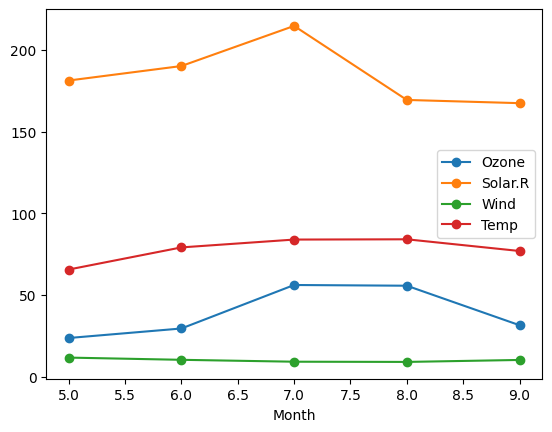

None 



In [35]:
#1 
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('data/airquality.csv')
print(df.head(), '\n')

#2
print(df.isnull().sum(), '\n')
print(df.isna().sum(axis=1).sum(), '\n')

#3
df_cleaned = df.reset_index(drop=True)

#4
ozone = df_cleaned['Ozone']
Q1 = ozone.quantile(0.25)
Q3 = ozone.quantile(0.75)
IQR = Q3 - Q1

outliers = ozone[(ozone < Q1 - IQR * 1.5) | (ozone > Q3 +IQR * 1.5)]
print(outliers, '\n')

df_cleaned = df_cleaned.loc[~df_cleaned['Ozone'].isin(outliers)]
print(df_cleaned, '\n')

#5
result = df_cleaned.groupby('Month')[['Ozone', 'Solar.R', 'Wind', 'Temp']].mean()
print(result, '\n')
result.plot(marker='o')
print(plt.show(), '\n')

In [36]:
#1
emp = pd.read_csv('data/emp.csv')
dept = pd.read_csv('data/dept.csv')

print(emp.head(), '\n')
print(dept.head(), '\n')

#2
df = emp.merge(dept, on = 'DEPTNO')
print(df.head(), '\n')

#3
print(df.pivot_table(index='LOC', columns='JOB', values='SAL', aggfunc='sum'), '\n')

#4
print(df.pivot_table(index='DNAME', columns='JOB', values='ENAME', aggfunc='count'))

   EMPNO   ENAME       JOB     MGR    HIREDATE   SAL    COMM  DEPTNO
0   7369   SMITH     CLERK  7902.0  1980-12-17   800     NaN      20
1   7499   ALLEN  SALESMAN  7698.0  1981-02-20  1600   300.0      30
2   7521    WARD  SALESMAN  7698.0  1981-02-22  1250   500.0      30
3   7566   JONES   MANAGER  7839.0  1981-04-02  2975     NaN      20
4   7654  MARTIN  SALESMAN  7698.0  1981-08-28  1250  1400.0      30 

   DEPTNO       DNAME       LOC
0      10  ACCOUNTING  NEW YORK
1      20    RESEARCH    DALLAS
2      30       SALES   CHICAGO
3      40  OPERATIONS    BOSTON
4      70    BRANCH_1     SEOUL 

   EMPNO   ENAME       JOB     MGR    HIREDATE   SAL    COMM  DEPTNO  \
0   7369   SMITH     CLERK  7902.0  1980-12-17   800     NaN      20   
1   7499   ALLEN  SALESMAN  7698.0  1981-02-20  1600   300.0      30   
2   7521    WARD  SALESMAN  7698.0  1981-02-22  1250   500.0      30   
3   7566   JONES   MANAGER  7839.0  1981-04-02  2975     NaN      20   
4   7654  MARTIN  SALESMAN  76